# Mini Project: Exploratory Data Analysis on India's COVID-19 Data
**Objective:** Analyze state-wise trends, recovery rates, and vaccination progress during India's first COVID-19 wave and the subsequent vaccination rollout[cite: 1].

**Data Sources:** 
* Case data: `imdevskp/covid-19-india-data`[cite: 1]
* Vaccination data: Our World in Data[cite: 1]

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visualizations
sns.set_theme(style="whitegrid")

## Step 1: Load the Data
Reading the datasets directly from their public GitHub and Our World in Data URLs using `pandas.read_csv()`[cite: 1].

In [6]:
# 1. Load COVID-19 case data
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/"
    "covid-19-india-data/master/complete.csv"
)

# 2. Load COVID-19 vaccination data
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/"
    "public/data/vaccinations/country_data/India.csv"
)

## Step 2 & 3: Inspect and Clean
Based on initial inspection, we need to fix two main data issues:
1. The `deaths` column is stored as text and needs to be numeric[cite: 1].
2. Several states are spelled multiple ways (e.g., Telengana/Telangana) or include "Union Territory of" prefixes, creating duplicates[cite: 1].

In [7]:
# Rename columns for easier programmatic access
cases.columns = [
    "date", "state", "lat", "long",
    "confirmed", "deaths", "cured", "new_cases",
    "new_deaths", "new_recovered",
]

# Convert 'date' to datetime objects
cases["date"] = pd.to_datetime(cases["date"])

# Clean 'deaths' column: convert to numeric, coerce errors, fill NaNs with 0, and cast to int
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)

# Standardize state/UT names to prevent grouping errors
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Drop any duplicate rows based on date and state
cases = cases.drop_duplicates(subset=["date", "state"])

# Calculate active cases
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

## Step 4: Explore with groupby and pivot_table
We create aggregated views of the data: national daily totals, the latest cumulative snapshot per state, and a pivot table tracking monthly case growth by state[cite: 1].

In [8]:
# 1. National daily totals
national = cases.groupby("date", as_index=False)[
    ["confirmed", "deaths", "cured", "new_cases"]
].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)

# 2. Latest snapshot per state, sorted by highest confirmed cases
latest = cases[cases["date"] == cases["date"].max()].copy()
latest = latest.sort_values("confirmed", ascending=False)
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)

# 3. Case growth by state and month using pivot_table
cases["month"] = cases["date"].dt.strftime("%Y-%m")
pivot = cases.pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)

## Step 5: Visualise Part 1 (National Trends and Hardest-Hit States)
Plotting the cumulative national curves, daily new cases, and identifying the states carrying the heaviest case load[cite: 1].

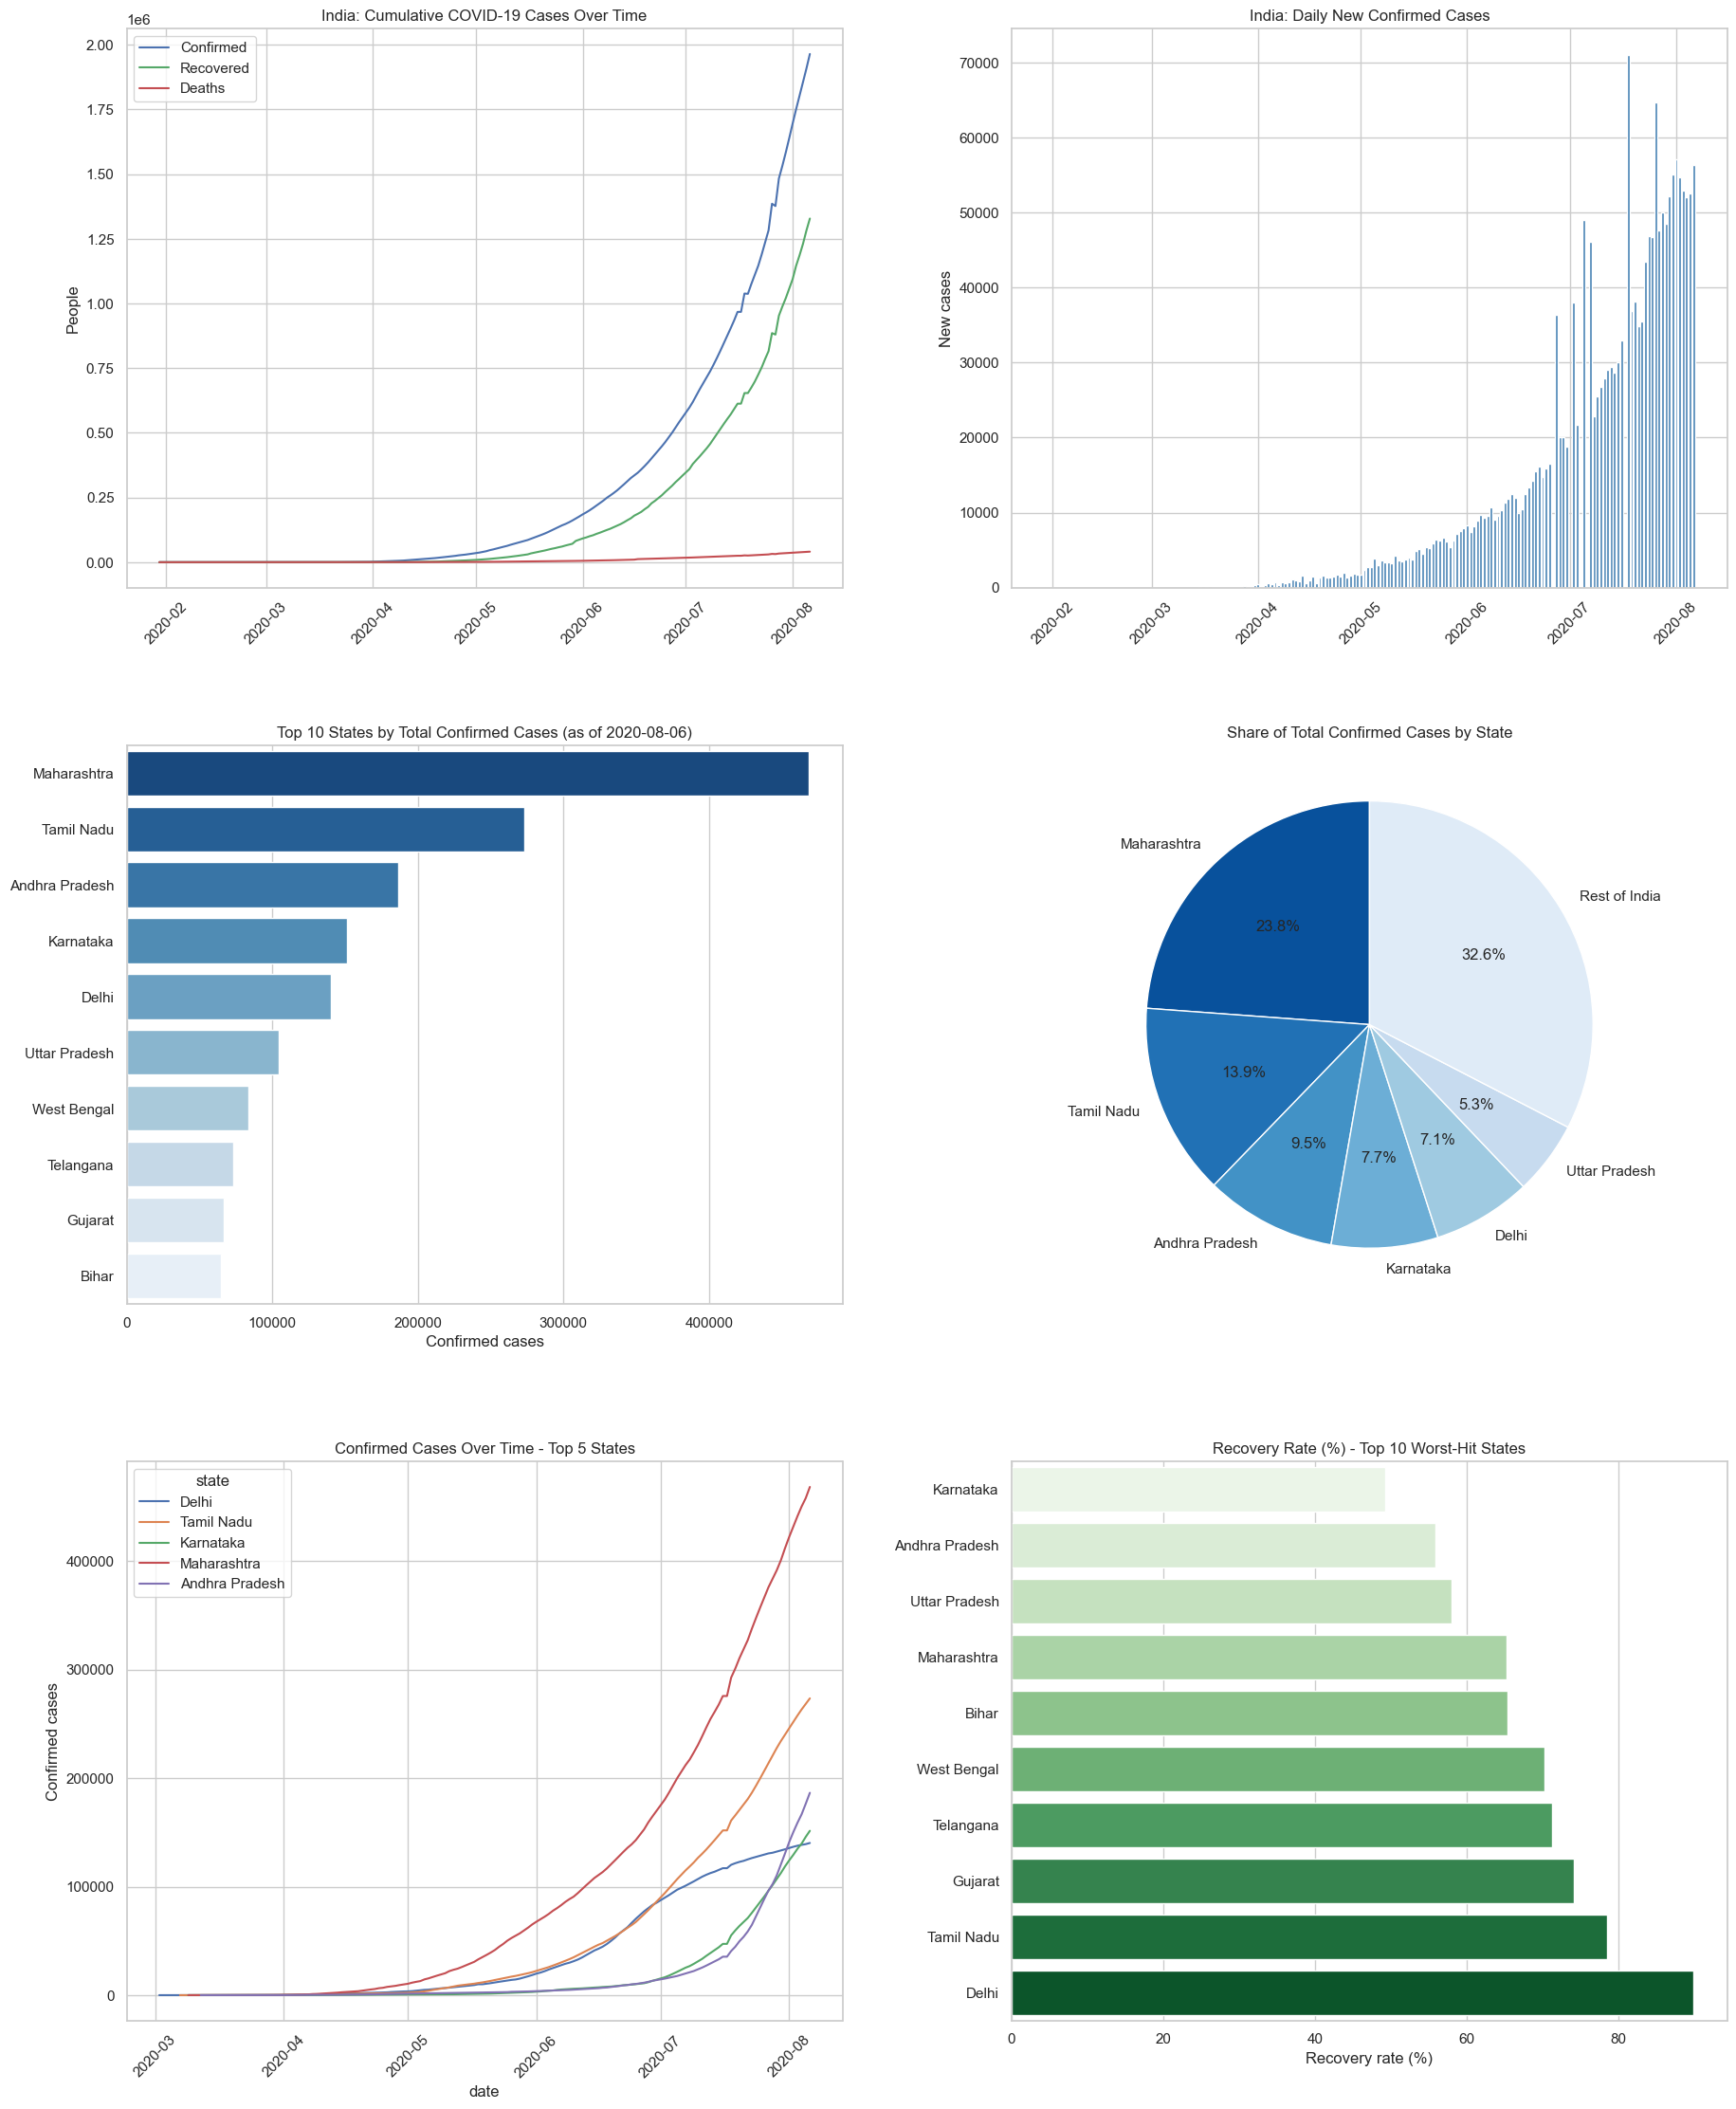

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
fig.tight_layout(pad=8.0)

# Chart 1: National Cumulative Cases Over Time
axes[0, 0].plot(national["date"], national["confirmed"], label="Confirmed", color="b")
axes[0, 0].plot(national["date"], national["cured"], label="Recovered", color="g")
axes[0, 0].plot(national["date"], national["deaths"], label="Deaths", color="r")
axes[0, 0].set_title("India: Cumulative COVID-19 Cases Over Time")
axes[0, 0].set_ylabel("People")
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Daily New Confirmed Cases
axes[0, 1].bar(national["date"], national["new_cases"], color="steelblue")
axes[0, 1].set_title("India: Daily New Confirmed Cases")
axes[0, 1].set_ylabel("New cases")
axes[0, 1].tick_params(axis='x', rotation=45)

# Chart 3: Top 10 States by Total Confirmed Cases
top_10 = latest.head(10)
sns.barplot(data=top_10, x="confirmed", y="state", ax=axes[1, 0], palette="Blues_r")
axes[1, 0].set_title(f"Top 10 States by Total Confirmed Cases (as of {cases['date'].max().date()})")
axes[1, 0].set_xlabel("Confirmed cases")
axes[1, 0].set_ylabel("")

# Chart 4: Share of Total Confirmed Cases by State (Pie Chart)
top_6 = latest.head(6)
rest_of_india = latest["confirmed"].sum() - top_6["confirmed"].sum()
pie_labels = top_6["state"].tolist() + ["Rest of India"]
pie_sizes = top_6["confirmed"].tolist() + [rest_of_india]

axes[1, 1].pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Blues_r", 7))
axes[1, 1].set_title("Share of Total Confirmed Cases by State")

# Chart 5: Confirmed Cases Over Time - Top 5 States
top_5_states = latest.head(5)["state"].tolist()
top_5_data = cases[cases["state"].isin(top_5_states)]
sns.lineplot(data=top_5_data, x="date", y="confirmed", hue="state", ax=axes[2, 0])
axes[2, 0].set_title("Confirmed Cases Over Time - Top 5 States")
axes[2, 0].set_ylabel("Confirmed cases")
axes[2, 0].tick_params(axis='x', rotation=45)

# Chart 6: Recovery Rate - Top 10 Worst-Hit States
sns.barplot(data=top_10.sort_values('recovery_rate', ascending=True), x="recovery_rate", y="state", ax=axes[2, 1], palette="Greens")
axes[2, 1].set_title("Recovery Rate (%) - Top 10 Worst-Hit States")
axes[2, 1].set_xlabel("Recovery rate (%)")
axes[2, 1].set_ylabel("")

plt.show()

## Step 5: Visualise Part 2 (Rates, Correlations, and Monthly Spread)
Investigating the relationship between recovery and death rates, seeing how metrics correlate, and analyzing the volatility of the outbreak using a monthly boxplot[cite: 1].

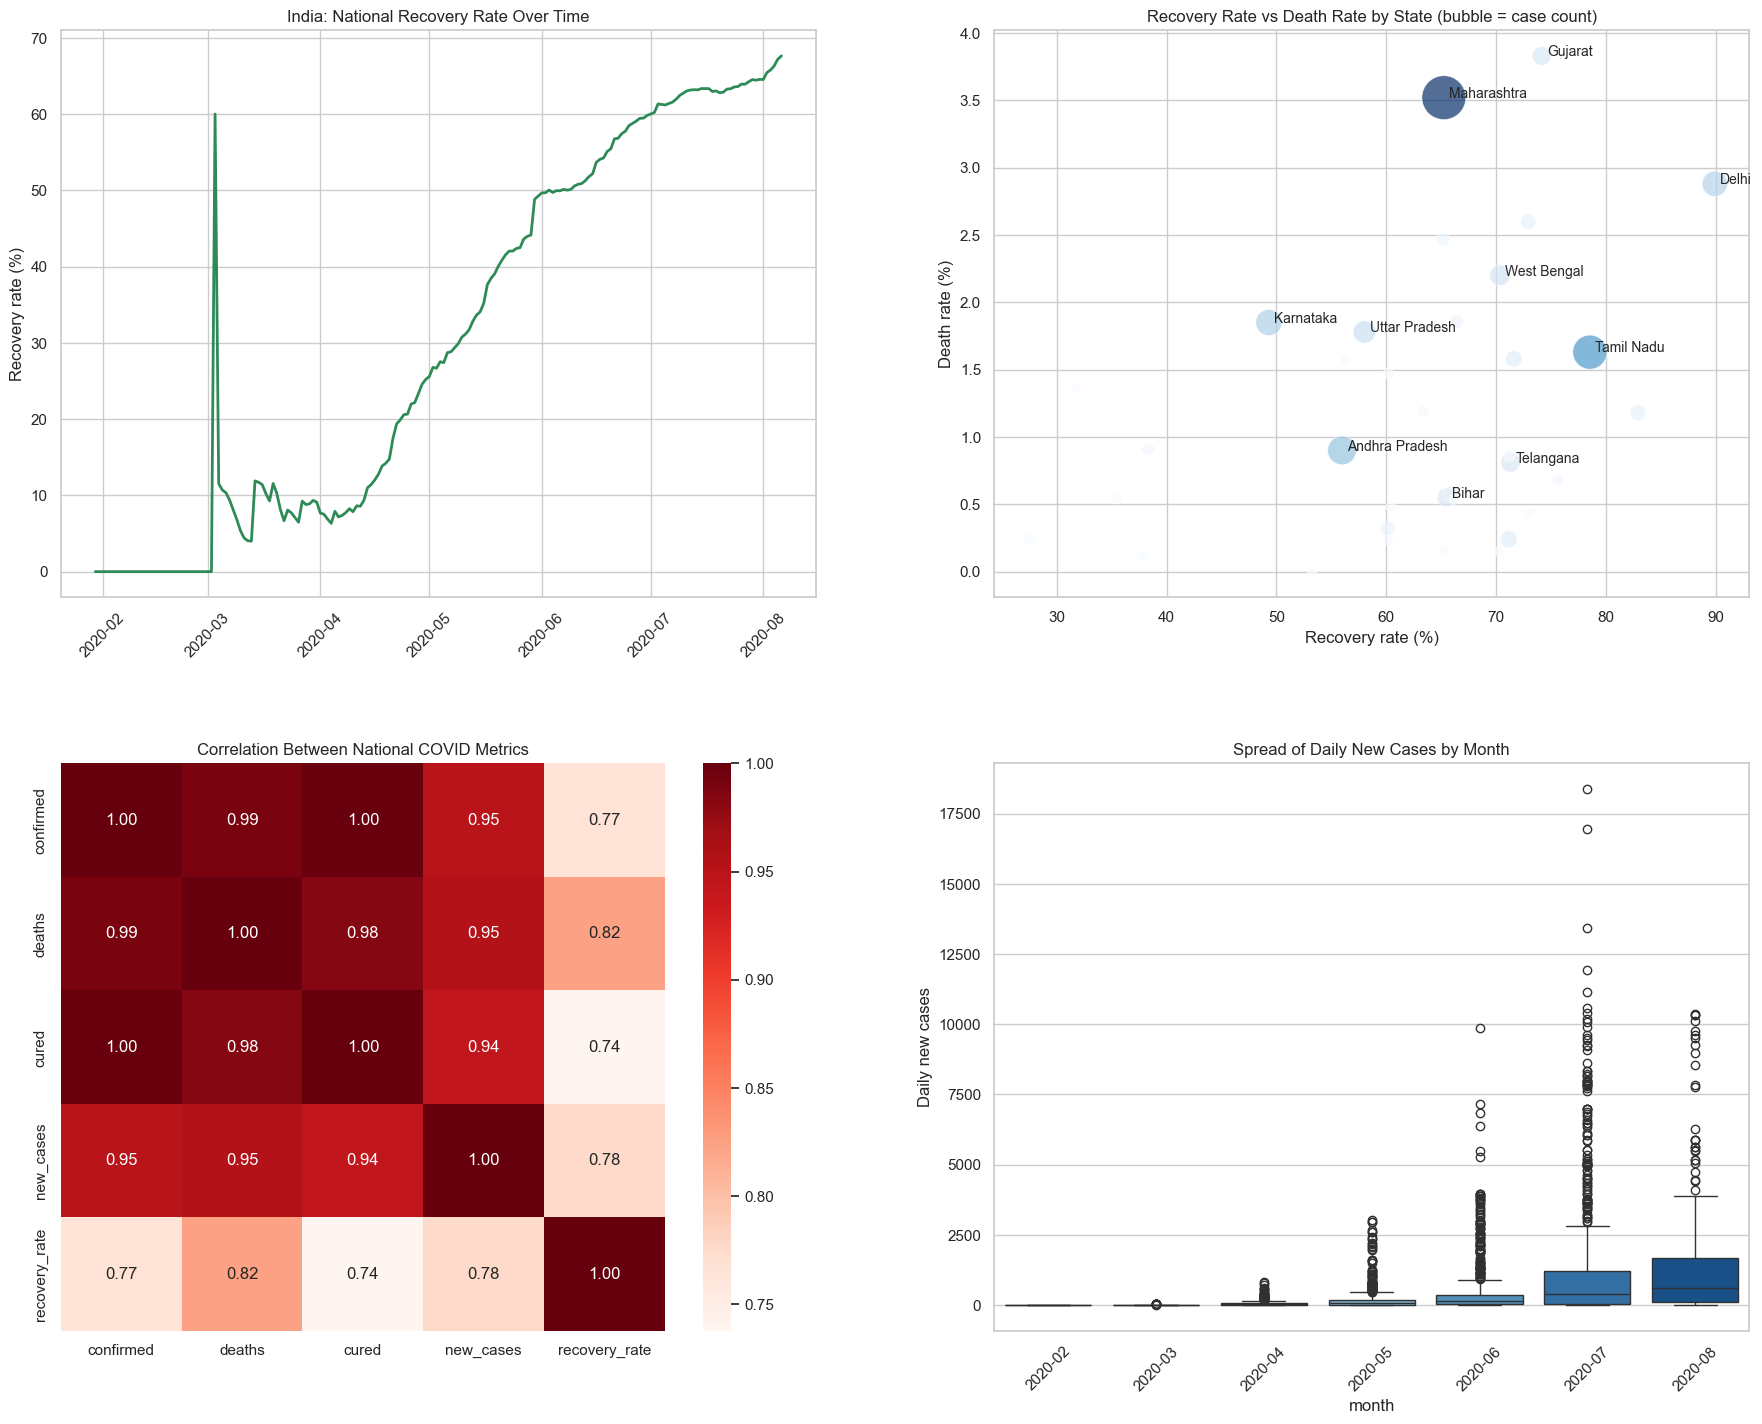

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.tight_layout(pad=8.0)

# Chart 7: National Recovery Rate Over Time
axes[0, 0].plot(national["date"], national["recovery_rate"], color="seagreen", linewidth=2)
axes[0, 0].set_title("India: National Recovery Rate Over Time")
axes[0, 0].set_ylabel("Recovery rate (%)")
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 8: Recovery Rate vs Death Rate by State
sns.scatterplot(
    data=latest, x="recovery_rate", y="death_rate", 
    size="confirmed", sizes=(50, 1000), alpha=0.7, 
    hue="confirmed", palette="Blues", ax=axes[0, 1], legend=False
)
axes[0, 1].set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
axes[0, 1].set_xlabel("Recovery rate (%)")
axes[0, 1].set_ylabel("Death rate (%)")
# Add labels for the top 10 worst-hit states
for i in range(len(top_10)):
    axes[0, 1].text(top_10.iloc[i]['recovery_rate']+0.5, top_10.iloc[i]['death_rate'], top_10.iloc[i]['state'], size='small')

# Chart 9: Correlation Matrix of National Metrics
corr_metrics = national[["confirmed", "deaths", "cured", "new_cases", "recovery_rate"]].corr()
sns.heatmap(corr_metrics, annot=True, cmap="Reds", fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Between National COVID Metrics")

# Chart 10: Spread of Daily New Cases by Month
sns.boxplot(data=cases[cases["new_cases"] > 0], x="month", y="new_cases", ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Spread of Daily New Cases by Month")
axes[1, 1].set_ylabel("Daily new cases")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.show()

## Step 5: Visualise Part 3 (Least-Affected States and Vaccination Follow-up)
Looking at the states that managed the lowest case counts in the first wave, and visualizing the massive scale of the national vaccination response from 2021 onwards[cite: 1].

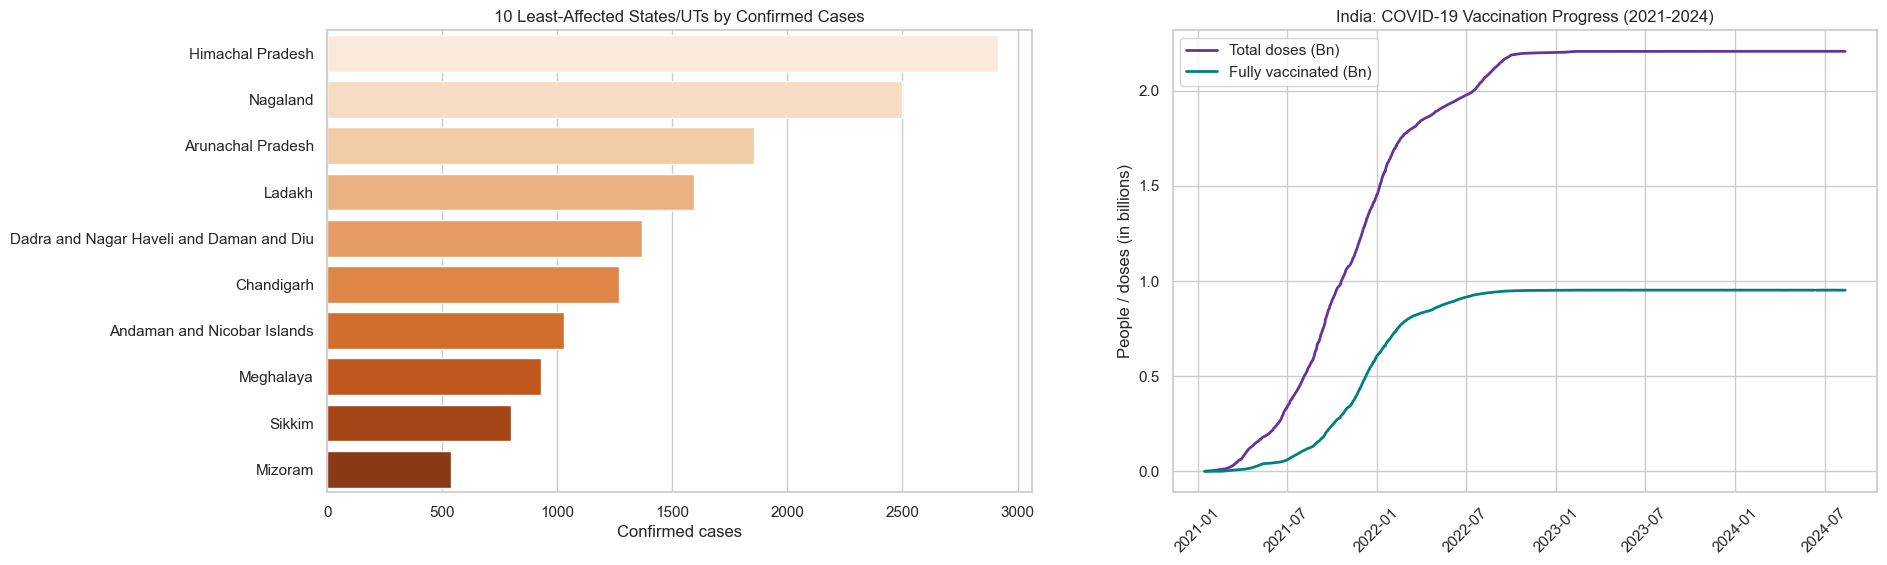

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Chart 11: 10 Least-Affected States
bottom_10 = latest.tail(10)
sns.barplot(data=bottom_10, x="confirmed", y="state", ax=axes[0], palette="Oranges")
axes[0].set_title("10 Least-Affected States/UTs by Confirmed Cases")
axes[0].set_xlabel("Confirmed cases")
axes[0].set_ylabel("")

# Chart 12: Vaccination Progress (2021-2024)
vax["date"] = pd.to_datetime(vax["date"])
vax["total_vaccinations_bn"] = vax["total_vaccinations"] / 1e9
vax["people_fully_vaccinated_bn"] = vax["people_fully_vaccinated"] / 1e9

axes[1].plot(vax["date"], vax["total_vaccinations_bn"], label="Total doses (Bn)", color="rebeccapurple", linewidth=2)
axes[1].plot(vax["date"], vax["people_fully_vaccinated_bn"], label="Fully vaccinated (Bn)", color="teal", linewidth=2)
axes[1].set_title("India: COVID-19 Vaccination Progress (2021-2024)")
axes[1].set_ylabel("People / doses (in billions)")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.show()